#Individual Assignment Topic :
Multi-Faceted Analysis of English Premier League Data: From Goals to Game Strategies

Name: Ali Ilhan Thani Bin Jalaluddin

Matric: 2222253

Section: 1

email: alithani.compsc@gmail.com

#Business Case
This analysis explores match results from the English Premier League (EPL) from 2000 to 2025 using a variety of data science techniques.


The goal of this project is to uncover patterns in team performance, scoring behavior, and match outcomes. All of the analysis methods are used ehich are descriptive, diagnostic, predictive, and prescriptive methods.


This analysis benefits clubs, analysts, and fans who want to understand what factors most influence match results and how teams can strategize more effectively.

#Methodology

The dataset was cleaned and filtered using Pandas. Descriptive analysis was conducted to summarize scoring trends. Diagnostic analysis explored relationships between outcomes and match conditions. Predictive modeling used PCA to estimate match outcomes from numerical features. Prescriptive analysis used decision tree to analyze the rules and win-rate statistics to offer strategic recommendations. Exploratory analysis and KMeans were used to uncover hidden match groupings. All of the data science question will be asked, and the list of variables used will be listed after each of the type of analysis is completed.

#Variables Used

FullTimeHomeGoals – Number of goals scored by home team

FullTimeAwayGoals – Number of goals scored by away team

Result – Match outcome (Home Win, Draw, Away Win)

HomeTeam – Name of home team

AwayTeam – Name of away team

HomeShots, AwayShots – Number of total shots per team

HomeShotsOnTarget, AwayShotsOnTarget – Shot accuracy

MatchDate, Season – Used for time-based trend analysis

HomeYellowCards, AwayRedCards – For discipline patterns

Referee – Used in diagnostic analysis

#Data Science Questions
1)Why do some English Premier League matches end in a draw, is it related to low total goal counts?

2) Which English Premier League teams have the highest average home goals, and what does this reveal about their scoring consistency across seasons?

3) Can English Premier League matches be naturally grouped into different types based on goals and shooting behavior?

4) Can clustering help identify outlier matches or extreme goal-scoring performances in the EPL?

5) Can we accurately predict the outcome of an English Premier League match (Home Win, Draw, or Away Win) using only the number of goals scored by the home and away teams?

6) Can we uncover underlying patterns in EPL match outcomes by applying Principal Component Analysis to full-time home and away goals?

7) What strategic advantage does playing at home offers, and how should teams adjust their approach based on home win rates?


8) What combination of full-time home and away goals most strongly determines the outcome of an EPL match, and how can these patterns guide team strategies?

9) Can a decision tree model be used to generate rule-based strategies that predict match outcomes in the EPL based on scoring patterns?

In [143]:
import pandas as pd

df = pd.read_csv('epl_final.csv')



In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # ← YOU NEED THIS ONE

# Optional but good to have
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [145]:
print(df.head())

    Season   MatchDate  HomeTeam       AwayTeam  FullTimeHomeGoals  \
0  2000/01  2000-08-19  Charlton       Man City                  4   
1  2000/01  2000-08-19   Chelsea       West Ham                  4   
2  2000/01  2000-08-19  Coventry  Middlesbrough                  1   
3  2000/01  2000-08-19     Derby    Southampton                  2   
4  2000/01  2000-08-19     Leeds        Everton                  2   

   FullTimeAwayGoals FullTimeResult  HalfTimeHomeGoals  HalfTimeAwayGoals  \
0                  0              H                  2                  0   
1                  2              H                  1                  0   
2                  3              A                  1                  1   
3                  2              D                  1                  2   
4                  0              H                  2                  0   

  HalfTimeResult  ...  HomeShotsOnTarget  AwayShotsOnTarget  HomeCorners  \
0              H  ...                 14

In [146]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9380 entries, 0 to 9379
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Season             9380 non-null   object
 1   MatchDate          9380 non-null   object
 2   HomeTeam           9380 non-null   object
 3   AwayTeam           9380 non-null   object
 4   FullTimeHomeGoals  9380 non-null   int64 
 5   FullTimeAwayGoals  9380 non-null   int64 
 6   FullTimeResult     9380 non-null   object
 7   HalfTimeHomeGoals  9380 non-null   int64 
 8   HalfTimeAwayGoals  9380 non-null   int64 
 9   HalfTimeResult     9380 non-null   object
 10  HomeShots          9380 non-null   int64 
 11  AwayShots          9380 non-null   int64 
 12  HomeShotsOnTarget  9380 non-null   int64 
 13  AwayShotsOnTarget  9380 non-null   int64 
 14  HomeCorners        9380 non-null   int64 
 15  AwayCorners        9380 non-null   int64 
 16  HomeFouls          9380 non-null   int64 


In [147]:
print(df['HomeTeam'].unique())


['Charlton' 'Chelsea' 'Coventry' 'Derby' 'Leeds' 'Leicester' 'Liverpool'
 'Sunderland' 'Tottenham' 'Man United' 'Arsenal' 'Bradford' 'Ipswich'
 'Middlesbrough' 'Everton' 'Man City' 'Newcastle' 'Southampton' 'West Ham'
 'Aston Villa' 'Bolton' 'Blackburn' 'Fulham' 'Birmingham' 'West Brom'
 'Portsmouth' 'Wolves' 'Norwich' 'Crystal Palace' 'Wigan' 'Reading'
 'Sheffield United' 'Watford' 'Hull' 'Stoke' 'Burnley' 'Blackpool' 'QPR'
 'Swansea' 'Cardiff' 'Bournemouth' 'Brighton' 'Huddersfield' 'Brentford'
 "Nott'm Forest" 'Luton']


In [148]:
# Convert Date column and extract season/year 
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Season'] = df['Date'].dt.year


In [149]:
# Add Match Result column based on full-time goals
if 'FullTimeHomeGoals' in df.columns and 'FullTimeAwayGoals' in df.columns:
    def get_result(row):
        if row['FullTimeHomeGoals'] > row['FullTimeAwayGoals']:
            return 'Home Win'
        elif row['FullTimeHomeGoals'] < row['FullTimeAwayGoals']:
            return 'Away Win'
        else:
            return 'Draw'

    df['Result'] = df.apply(get_result, axis=1)
    df['TotalGoals'] = df['FullTimeHomeGoals'] + df['FullTimeAwayGoals']

In [150]:
print("\nSample of added columns (Season, Result, TotalGoals):")
print(df[['MatchDate', 'Season', 'FullTimeHomeGoals', 'FullTimeAwayGoals', 'Result', 'TotalGoals']].head())


Sample of added columns (Season, Result, TotalGoals):
    MatchDate   Season  FullTimeHomeGoals  FullTimeAwayGoals    Result  \
0  2000-08-19  2000/01                  4                  0  Home Win   
1  2000-08-19  2000/01                  4                  2  Home Win   
2  2000-08-19  2000/01                  1                  3  Away Win   
3  2000-08-19  2000/01                  2                  2      Draw   
4  2000-08-19  2000/01                  2                  0  Home Win   

   TotalGoals  
0           4  
1           6  
2           4  
3           4  
4           2  


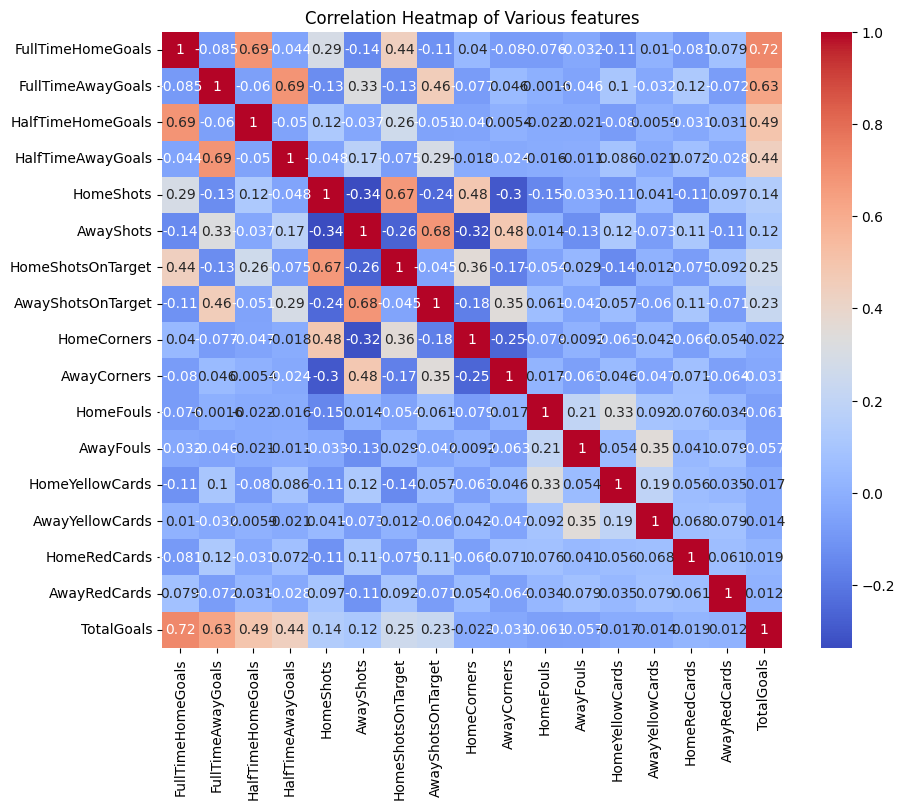

In [151]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Various features')
plt.show()



Average Goals per Season:
Season
2000/01    2.610526
2001/02    2.634211
2002/03    2.631579
2003/04    2.635821
2004/05    2.540299
2005/06    2.484211
2006/07    2.450000
2007/08    2.636842
2008/09    2.478947
2009/10    2.771053
2010/11    2.797368
2011/12    2.805263
2012/13    2.797368
2013/14    2.768421
2014/15    2.565789
2015/16    2.700000
2016/17    2.800000
2017/18    2.678947
2018/19    2.821053
2019/20    2.721053
2020/21    2.694737
2021/22    2.818421
2022/23    2.852632
2023/24    3.278947
2024/25    2.965714
Name: TotalGoals, dtype: float64


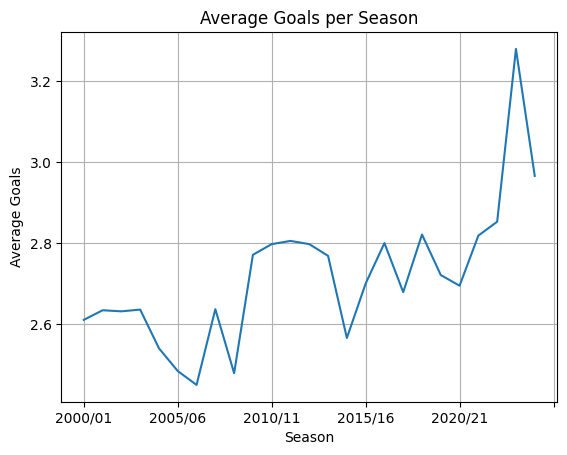

In [152]:
#  DESCRIPTIVE ANALYSIS

print("\nAverage Goals per Season:")
if 'Season' in df.columns:
    season_avg = df.groupby('Season')['TotalGoals'].mean()
    print(season_avg)
    season_avg.plot(kind='line', title='Average Goals per Season')
    plt.xlabel('Season')
    plt.ylabel('Average Goals')
    plt.grid(True)
    plt.show()


Goal distribution in Draws:


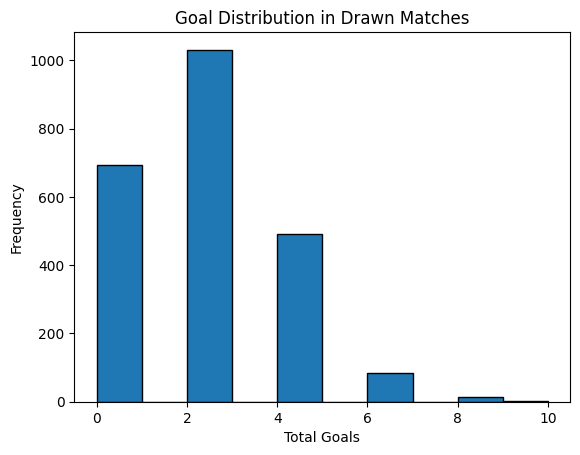

In [153]:
# 2. DIAGNOSTIC ANALYSIS

print("\nGoal distribution in Draws:")
if 'Result' in df.columns:
    draws = df[df['Result'] == 'Draw']
    plt.hist(draws['TotalGoals'], bins=10, edgecolor='black')
    plt.title('Goal Distribution in Drawn Matches')
    plt.xlabel('Total Goals')
    plt.ylabel('Frequency')
    plt.show()

#Data Science Question (Diagnostic Analysis)

1) Why do some English Premier League matches end in a draw, is it related to low total goal counts?

Variables: ['Result', 'TotalGoals']



In [154]:
# 4. EXPLORATORY ANALYSIS

print("\nTop 10 Consistent Home Scoring Teams:")
home_scoring_avg = df.groupby('HomeTeam')['FullTimeHomeGoals'].mean().sort_values(ascending=False).head(10)
print(home_scoring_avg)


Top 10 Consistent Home Scoring Teams:
HomeTeam
Man City      2.186667
Arsenal       2.147436
Liverpool     2.081370
Chelsea       2.057569
Man United    2.040512
Tottenham     1.835821
Brentford     1.653333
Blackpool     1.578947
Newcastle     1.565116
Everton       1.511677
Name: FullTimeHomeGoals, dtype: float64


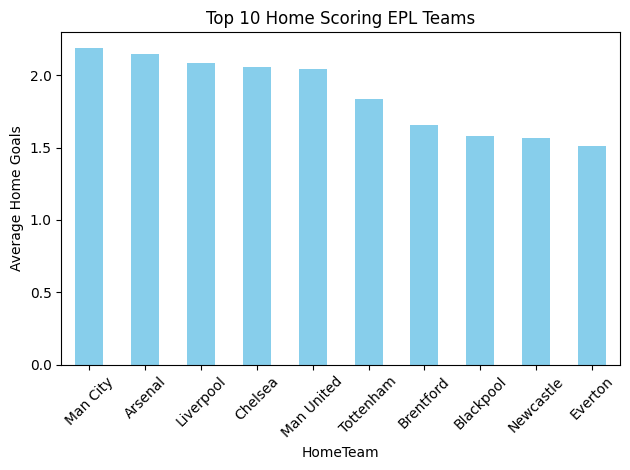

In [155]:


home_scoring_avg.plot(kind='bar', color='skyblue')
plt.title('Top 10 Home Scoring EPL Teams')
plt.ylabel('Average Home Goals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Data Science Question (Exploratory Question)

2) Which English Premier League teams have the highest average home goals, and what does this reveal about their scoring consistency across seasons?

Variables: ['HomeTeams' , 'FullTimeHomeGoals']

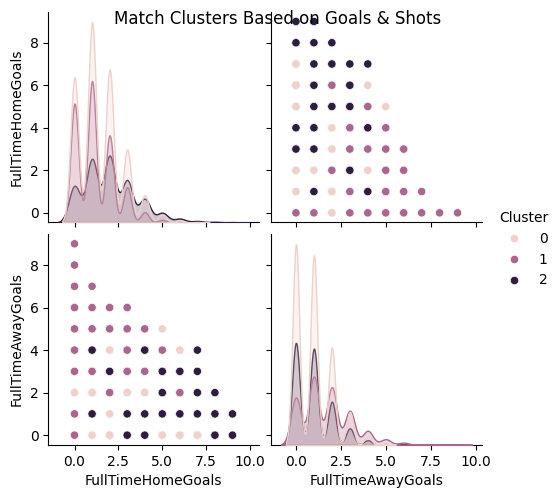

In [156]:

from sklearn.cluster import KMeans

# Add Match Result and TotalGoals columns (as done in previous cells)
def get_result(row):
    if row['FullTimeHomeGoals'] > row['FullTimeAwayGoals']:
        return 'Home Win'
    elif row['FullTimeHomeGoals'] < row['FullTimeAwayGoals']:
        return 'Away Win'
    else:
        return 'Draw'

df['Result'] = df.apply(get_result, axis=1)
df['TotalGoals'] = df['FullTimeHomeGoals'] + df['FullTimeAwayGoals']

X_cluster = df[['FullTimeHomeGoals', 'FullTimeAwayGoals', 'HomeShots', 'AwayShots']].dropna()
kmeans = KMeans(n_clusters=3, random_state=0).fit(X_cluster)
df['Cluster'] = kmeans.labels_

sns.pairplot(df, vars=['FullTimeHomeGoals', 'FullTimeAwayGoals'], hue='Cluster')
plt.suptitle('Match Clusters Based on Goals & Shots')
plt.show()

# analysis for improvement of knowledge after class

Redoing predictive analysis to make the prediction algorithm a better one instead of just relying for full time scores to predict who will win

Define Features (What We Actually Know Before Result)

In [157]:
# Features available before we know the match result
# This features doesnt directly impact the winner (Home/away) or draw, making it a good choice for predictive modeling
# These are statistics from the match itself, not the final score

predictive_features = [
    'HomeShots',           
    'AwayShots',           
    'HomeShotsOnTarget',   # Shots on target (quality chances)
    'AwayShotsOnTarget',
    'HomeCorners',         # Set piece opportunities
    'AwayCorners',
    'HomeFouls',           # Aggression/discipline
    'AwayFouls',
    'HomeYellowCards',     # Discipline issues
    'AwayYellowCards'
]

print("Features that will be used for prediction:")
for f in predictive_features:
    print(f"  • {f}")

Features that will be used for prediction:
  • HomeShots
  • AwayShots
  • HomeShotsOnTarget
  • AwayShotsOnTarget
  • HomeCorners
  • AwayCorners
  • HomeFouls
  • AwayFouls
  • HomeYellowCards
  • AwayYellowCards


Prepare the Data

In [158]:
# Create clean dataset
model_df = df[predictive_features + ['Result', 'MatchDate']].copy()

# Remove rows with missing values
initial_rows = len(model_df)
model_df = model_df.dropna()
print(f"Rows removed due to missing data: {initial_rows - len(model_df)}")
print(f"Final dataset size: {len(model_df)} rows")

# Separate features and target
X = model_df[predictive_features]
y = model_df['Result']

print(f"\nFeatures shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Rows removed due to missing data: 0
Final dataset size: 9380 rows

Features shape: (9380, 10)
Target distribution:
Result
Home Win    4299
Away Win    2768
Draw        2313
Name: count, dtype: int64


Split Data (Chronologically - No Future Leakage)

In [159]:
# Sort by date to prevent using future matches to predict past ones
model_df['MatchDate'] = pd.to_datetime(model_df['MatchDate'])
model_df = model_df.sort_values('MatchDate')

# Re-split after sorting
X = model_df[predictive_features]
y = model_df['Result']

# Split: first 80% for training, last 20% for testing
split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training data: {len(X_train)} matches ({model_df['MatchDate'].iloc[0].date()} to {model_df['MatchDate'].iloc[split_index-1].date()})")
print(f"Test data: {len(X_test)} matches ({model_df['MatchDate'].iloc[split_index].date()} to {model_df['MatchDate'].iloc[-1].date()})")

Training data: 7504 matches (2000-08-19 to 2020-07-26)
Test data: 1876 matches (2020-07-26 to 2025-05-05)


Scale Features (Important for Logistic Regression)

In [160]:
# Scale features to have mean=0, std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("The Features for logistic regression have been standardized (scaled to mean=0, std=1)")
print(f"  Before scaling - HomeShots range: {X_train['HomeShots'].min():.0f} to {X_train['HomeShots'].max():.0f}")
print(f"  After scaling - Mean: {X_train_scaled[:,0].mean():.4f}, Std: {X_train_scaled[:,0].std():.4f}")

The Features for logistic regression have been standardized (scaled to mean=0, std=1)
  Before scaling - HomeShots range: 0 to 43
  After scaling - Mean: -0.0000, Std: 1.0000


Train Both Models and Compare

In [161]:
# Train Random Forest (good for non-linear patterns)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

# Train Logistic Regression (simpler, more interpretable)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

# Compare results
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(f"Random Forest Accuracy:      {accuracy_score(y_test, rf_pred):.4f}")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred):.4f}")


MODEL COMPARISON
Random Forest Accuracy:      0.5661
Logistic Regression Accuracy: 0.5954


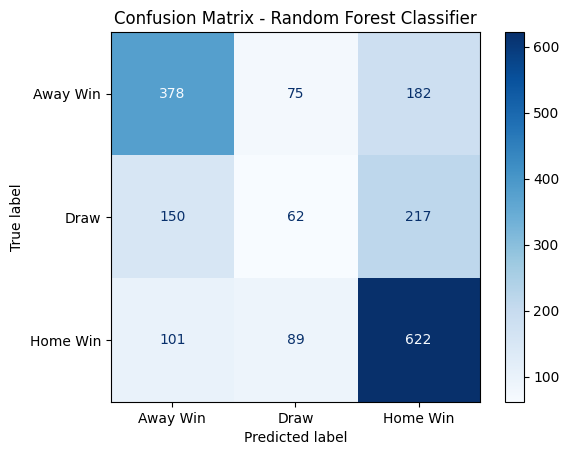


CONFUSION MATRIX (Numerical Values)
Rows = Actual, Columns = Predicted
Labels: ['Away Win', 'Draw', 'Home Win']

Matrix:
[[378  75 182]
 [150  62 217]
 [101  89 622]]


In [162]:
# Get predictions from Random Forest
rf_pred = rf_model.predict(X_test_scaled)

# Create confusion matrix
cm = confusion_matrix(y_test, rf_pred, labels=rf_model.classes_)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()

# Print numerical values
print("\n" + "="*50)
print("CONFUSION MATRIX (Numerical Values)")
print("="*50)
print(f"Rows = Actual, Columns = Predicted")
print(f"Labels: {list(rf_model.classes_)}")
print("\nMatrix:")
print(cm)

Detailed Results for Best Model

In [163]:
# Choose the better model
if accuracy_score(y_test, rf_pred) > accuracy_score(y_test, lr_pred):
    best_model = rf_model
    best_pred = rf_pred
    best_name = "Random Forest"
else:
    best_model = lr_model
    best_pred = lr_pred
    best_name = "Logistic Regression"

print(f"\n Best Model: {best_name}")
print(f" Accuracy: {accuracy_score(y_test, best_pred):.4f}")
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, best_pred))


 Best Model: Logistic Regression
 Accuracy: 0.5954

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Away Win       0.63      0.63      0.63       635
        Draw       0.31      0.06      0.10       429
    Home Win       0.60      0.85      0.70       812

    accuracy                           0.60      1876
   macro avg       0.51      0.51      0.48      1876
weighted avg       0.54      0.60      0.54      1876



Confusion Matrix for 2nd try of predictive analysis (logistic regression)

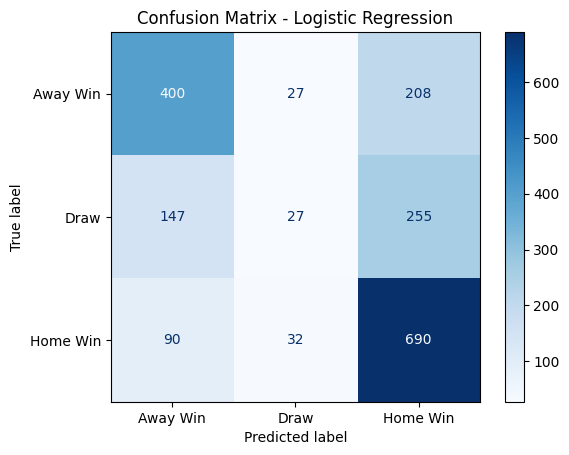


📖 How to read this matrix:
  • Rows = Actual results
  • Columns = Predicted results
  • Diagonal = Correct predictions
  • Off-diagonal = Where the model got confused


In [164]:
# Visualize where the model makes mistakes
cm = confusion_matrix(y_test, best_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

print("\n📖 How to read this matrix:")
print("  • Rows = Actual results")
print("  • Columns = Predicted results")  
print("  • Diagonal = Correct predictions")
print("  • Off-diagonal = Where the model got confused")

In [165]:
# Random Forest Results

print("\n" + "="*50)
print("LOGISTIC REGRESSION - CLASSIFICATION REPORT")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(classification_report(y_test, lr_pred))



LOGISTIC REGRESSION - CLASSIFICATION REPORT
Accuracy: 0.5954
              precision    recall  f1-score   support

    Away Win       0.63      0.63      0.63       635
        Draw       0.31      0.06      0.10       429
    Home Win       0.60      0.85      0.70       812

    accuracy                           0.60      1876
   macro avg       0.51      0.51      0.48      1876
weighted avg       0.54      0.60      0.54      1876



Confusion Matrix for 2nd try of predictive analysis (random forest classifier)

In [166]:
# Which stats matter most for prediction?
if best_name == "Random Forest":
    print (best_name)
    importance_df = pd.DataFrame({
        'feature': predictive_features,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['feature'], importance_df['importance'])
    plt.xlabel('Importance Score')
    plt.title('Most Important Factors for Predicting Match Results')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("\n Top 3 Most Important Factors:")
    for i, row in importance_df.head(3).iterrows():
        print(f"  {i+1}. {row['feature']}: {row['importance']:.3f}")
else:
    # For Logistic Regression, show coefficients
    print (best_name)
    coef_df = pd.DataFrame({
        'feature': predictive_features,
        'coefficient': best_model.coef_[0]
    }).sort_values('coefficient', ascending=False)
    
    print("\n Features with strongest influence:")
    print("  Positive coefficient = increases chance of Home Win")
    print("  Negative coefficient = increases chance of Away Win")
    print("\nTop 3 (promote Home Win):")
    for i, row in coef_df.head(3).iterrows():
        print(f"  {i+1}. {row['feature']}: {row['coefficient']:.3f}")
    print("\nTop 3 (promote Away Win):")
    for i, row in coef_df.tail(3).iterrows():
        print(f"  {i+1}. {row['feature']}: {row['coefficient']:.3f}")

Logistic Regression

 Features with strongest influence:
  Positive coefficient = increases chance of Home Win
  Negative coefficient = increases chance of Away Win

Top 3 (promote Home Win):
  4. AwayShotsOnTarget: 0.578
  9. HomeYellowCards: 0.109
  5. HomeCorners: 0.106

Top 3 (promote Away Win):
  10. AwayYellowCards: -0.080
  6. AwayCorners: -0.171
  3. HomeShotsOnTarget: -0.537


In [188]:
predictive_features_10 = [
    'HomeShots', 'AwayShots', 'HomeShotsOnTarget', 'AwayShotsOnTarget',
    'HomeCorners', 'AwayCorners', 'HomeFouls', 'AwayFouls',
    'HomeYellowCards', 'AwayYellowCards'
]


 Best Model: Logistic Regression


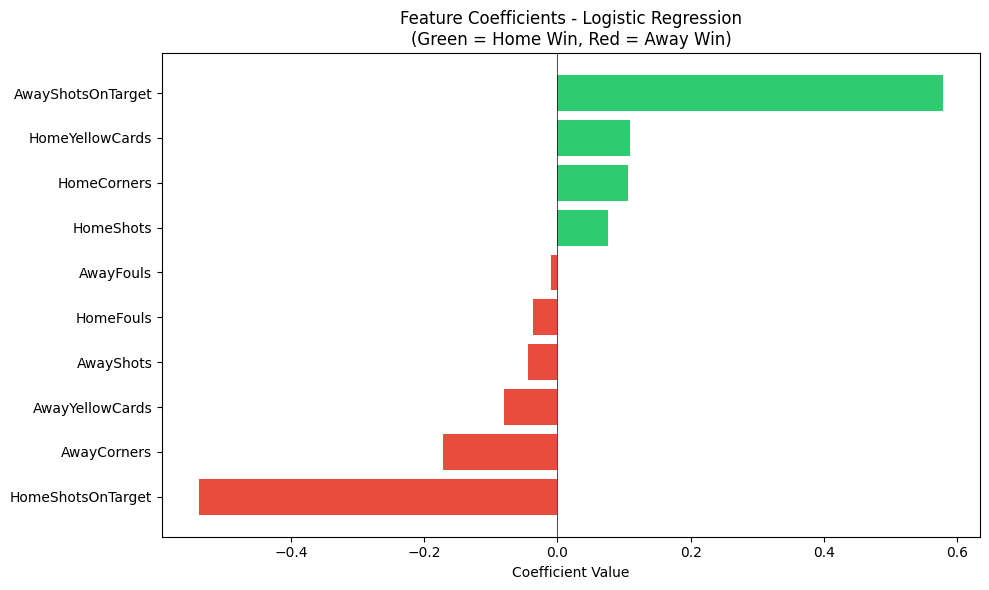


 Features with strongest influence:
  Positive coefficient = increases chance of Home Win
  Negative coefficient = increases chance of Away Win

Top 3 (promote Home Win):
  4. AwayShotsOnTarget: 0.578
  9. HomeYellowCards: 0.109
  5. HomeCorners: 0.106

Top 3 (promote Away Win):
  10. AwayYellowCards: -0.080
  6. AwayCorners: -0.171
  3. HomeShotsOnTarget: -0.537


In [189]:
# Which stats matter most for prediction?
if best_name == "Random Forest":
    print(f"\n Best Model: {best_name}")
    
    # Get feature names from the model
    feature_names = predictive_features_10 if best_model.n_features_in_ == 10 else predictive_features
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Bar chart
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['feature'], importance_df['importance'], color='forestgreen')
    plt.xlabel('Importance Score')
    plt.title(f'Most Important Factors - {best_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("\n Top 3 Most Important Factors:")
    for i, row in importance_df.head(3).iterrows():
        print(f"  {i+1}. {row['feature']}: {row['importance']:.3f}")
        
else:
    print(f"\n Best Model: {best_name}")
    
    # Get feature names from the model
    feature_names = predictive_features_10 if best_model.n_features_in_ == 10 else predictive_features
    
    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': best_model.coef_[0]
    }).sort_values('coefficient', ascending=False)
    
    # Bar chart
    plt.figure(figsize=(10, 6))
    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in coef_df['coefficient']]
    plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.xlabel('Coefficient Value')
    plt.title(f'Feature Coefficients - {best_name}\n(Green = Home Win, Red = Away Win)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("\n Features with strongest influence:")
    print("  Positive coefficient = increases chance of Home Win")
    print("  Negative coefficient = increases chance of Away Win")
    print("\nTop 3 (promote Home Win):")
    for i, row in coef_df.head(3).iterrows():
        print(f"  {i+1}. {row['feature']}: {row['coefficient']:.3f}")
    print("\nTop 3 (promote Away Win):")
    for i, row in coef_df.tail(3).iterrows():
        print(f"  {i+1}. {row['feature']}: {row['coefficient']:.3f}")


 Best Model: Logistic Regression


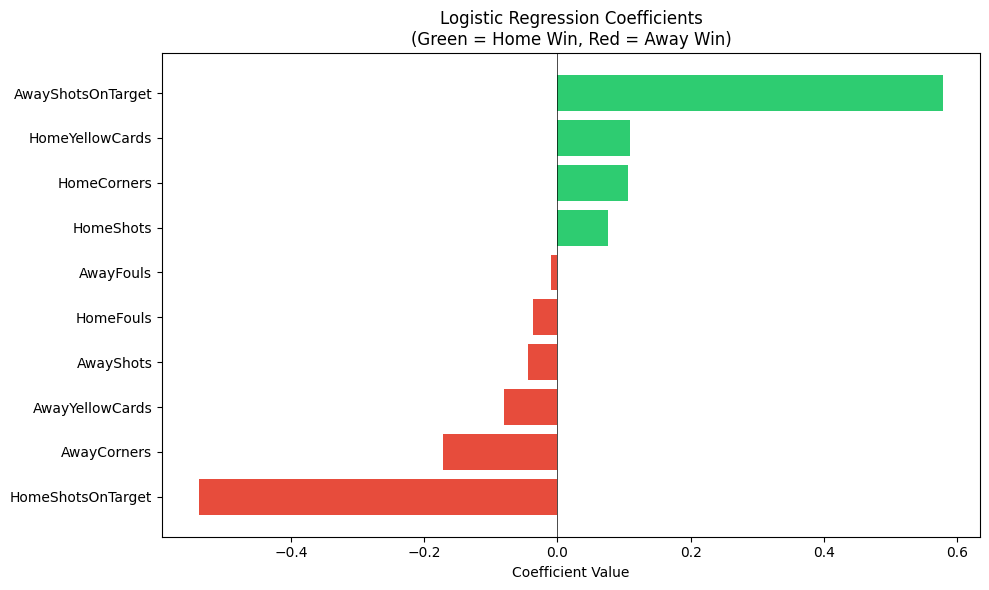

In [194]:
# ============================================
# LOGISTIC REGRESSION COEFFICIENTS
# ============================================
print(f"\n Best Model: {best_name}")

# Get feature names for Logistic Regression
feature_names_lr = predictive_features_10 if lr_model.n_features_in_ == 10 else predictive_features

coef_df = pd.DataFrame({
    'feature': feature_names_lr,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', ascending=False)

# Bar chart - Logistic Regression
plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Coefficients\n(Green = Home Win, Red = Away Win)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



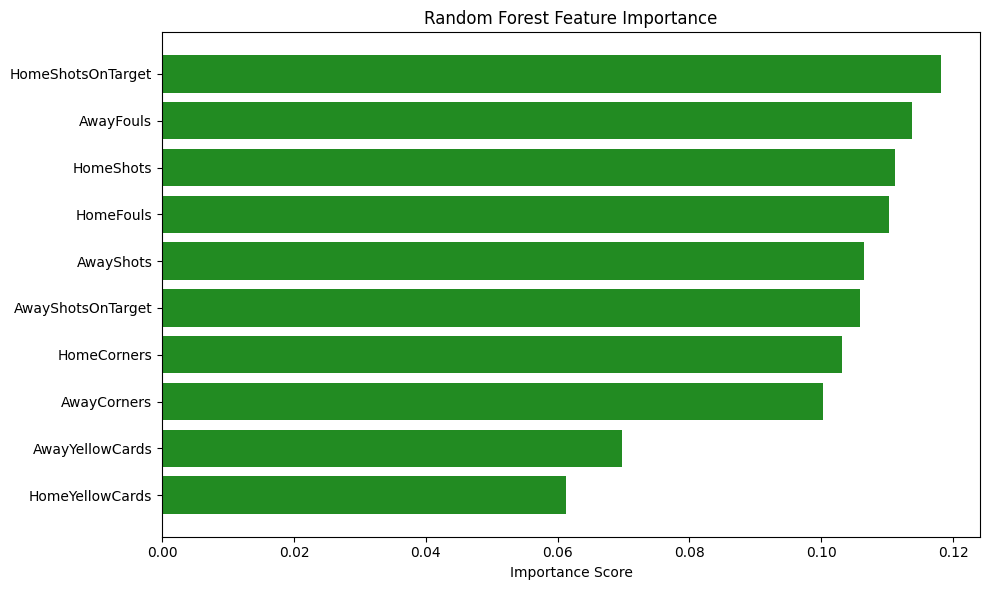


 Top 3 Most Important Factors:
  3. HomeShotsOnTarget: 0.118
  8. AwayFouls: 0.114
  1. HomeShots: 0.111


In [195]:
# ============================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================
print("\n" + "="*50)

# Get feature names for Random Forest
feature_names_rf = predictive_features_10 if rf_model.n_features_in_ == 10 else predictive_features

importance_df = pd.DataFrame({
    'feature': feature_names_rf,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Bar chart - Random Forest
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='forestgreen')
plt.xlabel('Importance Score')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n Top 3 Most Important Factors:")
for i, row in importance_df.head(3).iterrows():
    print(f"  {i+1}. {row['feature']}: {row['importance']:.3f}")

In [167]:
# Look at actual vs predicted for test matches
sample_size = min(20, len(y_test))
sample_df = pd.DataFrame({
    'Actual': y_test.values[:sample_size],
    'Predicted': best_pred[:sample_size],
    'Correct': y_test.values[:sample_size] == best_pred[:sample_size]
})

print("\n" + "="*50)
print("SAMPLE PREDICTIONS (First 20 Test Matches)")
print("="*50)
print(sample_df.to_string(index=True))

correct_count = sample_df['Correct'].sum()
print(f"\n✅ Correct in this sample: {correct_count}/{sample_size} ({correct_count/sample_size*100:.0f}%)")


SAMPLE PREDICTIONS (First 20 Test Matches)
      Actual Predicted  Correct
0   Away Win  Away Win     True
1   Away Win  Home Win    False
2   Home Win  Home Win     True
3   Away Win  Away Win     True
4   Home Win  Away Win    False
5       Draw  Home Win    False
6   Home Win  Away Win    False
7   Away Win  Home Win    False
8   Home Win  Home Win     True
9   Away Win  Away Win     True
10  Away Win  Away Win     True
11  Away Win  Home Win    False
12  Away Win  Away Win     True
13  Away Win  Away Win     True
14  Home Win  Home Win     True
15  Home Win  Home Win     True
16  Home Win  Home Win     True
17  Away Win  Away Win     True
18  Away Win  Away Win     True
19  Away Win  Away Win     True

✅ Correct in this sample: 14/20 (70%)


# What we have done

choosing 9 columns to be used as the features of

# Based on the features with the strongest coefficient, which one is for top 3 home and away win, it doesnt make sense as below are the result

Features with strongest influence:
  Positive coefficient = increases chance of Home Win
  Negative coefficient = increases chance of Away Win

Top 3 (promote Home Win):
  4. AwayShotsOnTarget: 0.578
  9. HomeYellowCards: 0.109
  5. HomeCorners: 0.106

Top 3 (promote Away Win):
  10. AwayYellowCards: -0.080
  6. AwayCorners: -0.171
  3. HomeShotsOnTarget: -0.537

So, we are going to reduce the cfeatures used.

In [168]:
predictive_features = [
    'HomeShotsOnTarget',   # Shots on target (quality chances)
    'AwayShotsOnTarget',
    'HomeCorners',         # Set piece opportunities
    'AwayCorners',
    'HomeFouls',           # Aggression/discipline
    'AwayFouls',
]

print("Features that will be used for prediction (reduced):")
for f in predictive_features:
    print(f"  • {f}")

Features that will be used for prediction (reduced):
  • HomeShotsOnTarget
  • AwayShotsOnTarget
  • HomeCorners
  • AwayCorners
  • HomeFouls
  • AwayFouls


In [169]:

df_temp = df[predictive_features + ['Result', 'MatchDate']].copy()
df_temp = df_temp.dropna()
df_temp['MatchDate'] = pd.to_datetime(df_temp['MatchDate'])
df_temp = df_temp.sort_values('MatchDate')

X = df_temp[predictive_features]
y = df_temp['Result']

# Chronological split
split_idx = int(len(df_temp) * 0.8)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Data ready: {len(X_train)} train, {len(X_test)} test samples")

✓ Data ready: 7504 train, 1876 test samples


Hyperparameter Tuning: Regularization (C):

Testing C values from 0.001 to 100 to find the 
best balance between bias and variance.

In [170]:
# Smaller C = stronger losgistic regularization (simpler model)
# Larger C = weaker regularization (more complex model)

C_values = [0.001, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]

print("Testing these C values:")
for c in C_values:
    print(f"  • C = {c:6.3f} (regularization strength = {1/c:.3f})")

Testing these C values:
  • C =  0.001 (regularization strength = 1000.000)
  • C =  0.010 (regularization strength = 100.000)
  • C =  0.050 (regularization strength = 20.000)
  • C =  0.100 (regularization strength = 10.000)
  • C =  0.500 (regularization strength = 2.000)
  • C =  1.000 (regularization strength = 1.000)
  • C =  2.000 (regularization strength = 0.500)
  • C =  5.000 (regularization strength = 0.200)
  • C = 10.000 (regularization strength = 0.100)
  • C = 50.000 (regularization strength = 0.020)
  • C = 100.000 (regularization strength = 0.010)


changing the random_state from 42(from chatgpt) to 37 just because it is my favourite number. supposedly it doesnt affect too much. just need to be consistent wwith it in the model

In [171]:
# Cell 5: Train final model with best C (FIXED)
best_C = None
best_acc = 0

C_values = [0.001, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]

for C in C_values:
    lr = LogisticRegression(C=C, max_iter=1000, random_state=37)
    lr.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, lr.predict(X_test_scaled))
    if acc > best_acc:
        best_acc = acc
        best_C = C

print(f"Best C found: {best_C:.3f} (Accuracy: {best_acc:.4f})")



Best C found: 0.010 (Accuracy: 0.5965)


In [172]:
# train logistic model
final_model = LogisticRegression(C=best_C, max_iter=1000, random_state=37)
final_model.fit(X_train_scaled, y_train)
final_pred = final_model.predict(X_test_scaled)




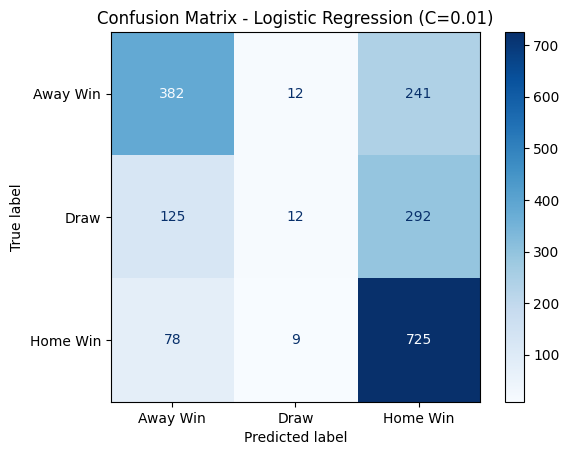

In [173]:
# Confusion Matrix for Logistic Regression (C=0.01)
cm_lr = confusion_matrix(y_test, final_pred, labels=final_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=final_model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression (C=0.01)')
plt.show()

In [174]:
print(f"Final Model Test Accuracy: {accuracy_score(y_test, final_pred):.4f}")
print("Classification Report: Confusion Matrix - Logistic Regression (C=0.01)\n")
print(classification_report(y_test, final_pred))

Final Model Test Accuracy: 0.5965
Classification Report: Confusion Matrix - Logistic Regression (C=0.01)

              precision    recall  f1-score   support

    Away Win       0.65      0.60      0.63       635
        Draw       0.36      0.03      0.05       429
    Home Win       0.58      0.89      0.70       812

    accuracy                           0.60      1876
   macro avg       0.53      0.51      0.46      1876
weighted avg       0.55      0.60      0.53      1876



In [183]:
# Logistic Regression Coefficients (C=0.01) - Text Only
coef_df = pd.DataFrame({
    'Feature': predictive_features,
    'Coefficient': final_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("\n" + "="*50)
print("LOGISTIC REGRESSION COEFFICIENTS (C=0.01)")
print("="*50)
print("  Positive = favors Home Win | Negative = favors Away Win\n")

for i, row in coef_df.head(3).iterrows():
    print(f"  {i+1}. {row['Feature']}: {row['Coefficient']:.3f}")
print("\n Top 3 (Away Win):")
for i, row in coef_df.tail(3).iterrows():
    print(f"  {i+1}. {row['Feature']}: {row['Coefficient']:.3f}")


LOGISTIC REGRESSION COEFFICIENTS (C=0.01)
  Positive = favors Home Win | Negative = favors Away Win

  2. AwayShotsOnTarget: 0.498
  3. HomeCorners: 0.103
  5. HomeFouls: -0.007

 Top 3 (Away Win):
  6. AwayFouls: -0.037
  4. AwayCorners: -0.158
  1. HomeShotsOnTarget: -0.444


But this logistic regression have a bad draw prediction, which is only 0.03 recall. This means that the model now only predict 3% of the draw mathces. For example, if there are 100 draw samples, the model only can predict 3

Lets try to repair it down below by balanced the weight class

This logistic regression model also reduced accuracy by 0.0009 compared to previous one

In [176]:
# Train logistic model with class_weight='balanced'
final_model_balanced = LogisticRegression(C=best_C, max_iter=1000, random_state=42, class_weight='balanced')
final_model_balanced.fit(X_train_scaled, y_train)
final_pred_balanced = final_model_balanced.predict(X_test_scaled)



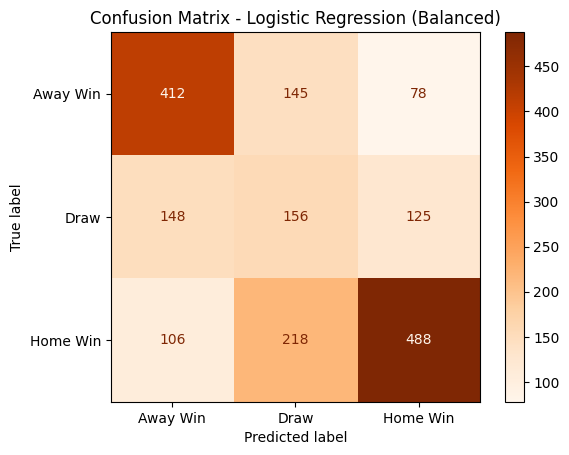

In [177]:
# Confusion Matrix for Logistic Regression (Balanced)
cm_lr_balanced = confusion_matrix(y_test, final_pred_balanced, labels=final_model_balanced.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr_balanced, display_labels=final_model_balanced.classes_)
disp.plot(cmap='Oranges')
plt.title('Confusion Matrix - Logistic Regression (Balanced)')
plt.show()

In [178]:
print(f"\n Final Model Test Accuracy: {accuracy_score(y_test, final_pred_balanced):.4f}")
print("\n Classification Report: Logistic Regression (Balanced)\n")
print(classification_report(y_test, final_pred_balanced))


 Final Model Test Accuracy: 0.5629

 Classification Report: Logistic Regression (Balanced)

              precision    recall  f1-score   support

    Away Win       0.62      0.65      0.63       635
        Draw       0.30      0.36      0.33       429
    Home Win       0.71      0.60      0.65       812

    accuracy                           0.56      1876
   macro avg       0.54      0.54      0.54      1876
weighted avg       0.58      0.56      0.57      1876



In [179]:
# Logistic Regression Coefficients (Balanced) - Text Only
coef_df_balanced = pd.DataFrame({
    'Feature': predictive_features,
    'Coefficient': final_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("\n" + "="*50)
print("LOGISTIC REGRESSION COEFFICIENTS (BALANCED)")
print("="*50)
print("  Positive = favors Home Win | Negative = favors Away Win\n")
print("\n Top 3 (Home Win):")
for i, row in coef_df_balanced.head(3).iterrows():
    print(f"  {i+1}. {row['Feature']}: {row['Coefficient']:.3f}")
print("\n Top 3 (Away Win):")
for i, row in coef_df_balanced.tail(3).iterrows():
    print(f"  {i+1}. {row['Feature']}: {row['Coefficient']:.3f}")


LOGISTIC REGRESSION COEFFICIENTS (BALANCED)
  Positive = favors Home Win | Negative = favors Away Win


 Top 3 (Home Win):
  2. AwayShotsOnTarget: 0.498
  3. HomeCorners: 0.103
  5. HomeFouls: -0.007

 Top 3 (Away Win):
  6. AwayFouls: -0.037
  4. AwayCorners: -0.158
  1. HomeShotsOnTarget: -0.444


In order for our logistic regression model to recall more Draw games (by 33%), we unfortunately have deduct Win by 15% but improve AwayWin by 5%. Our accuracy have also be deducted by around 3% which is quite a huge toll in order for our current model to focus more on draw games.

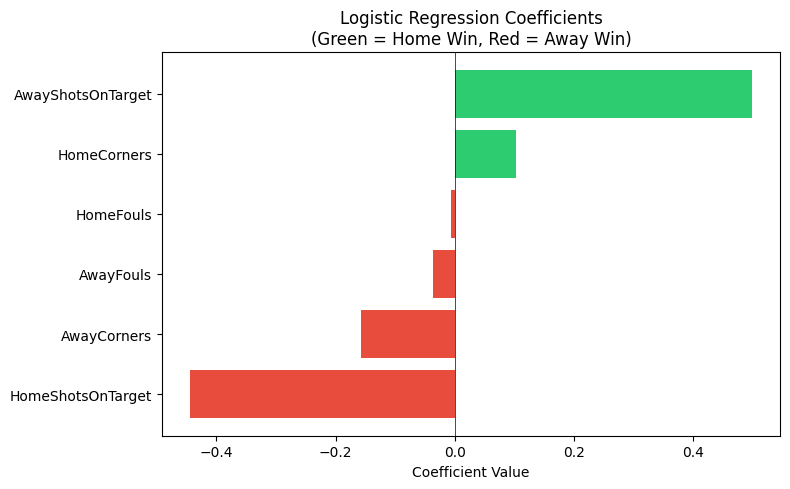

In [180]:
# Logistic Regression Coefficients
coef_df = pd.DataFrame({
    'Feature': predictive_features,
    'Coefficient': final_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(8, 5))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Coefficients\n(Green = Home Win, Red = Away Win)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

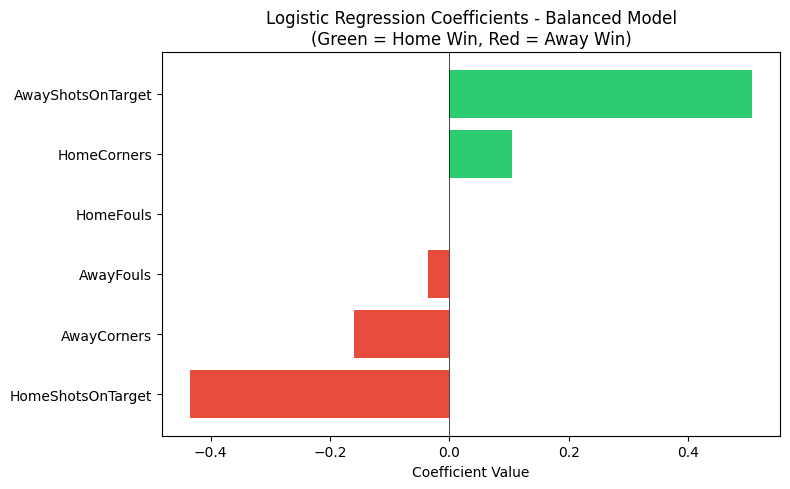

In [181]:
# Logistic Regression Coefficients (Balanced Model)
coef_df_balanced = pd.DataFrame({
    'Feature': predictive_features,
    'Coefficient': final_model_balanced.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(8, 5))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in coef_df_balanced['Coefficient']]
plt.barh(coef_df_balanced['Feature'], coef_df_balanced['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Coefficients - Balanced Model\n(Green = Home Win, Red = Away Win)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Now, we will do random forest classifier

In [184]:
# CELL X: Hyperparameter Tuning for Random Forest
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=37)
grid_search = GridSearchCV(rf_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV accuracy: 0.5371


In [ ]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,      # More trees = more stable
    max_depth=10,          # Limit depth to prevent overfitting
    class_weight='balanced',
    random_state=37
)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

print("RANDOM FOREST RESULTS:")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(classification_report(y_test, rf_pred))

RANDOM FOREST RESULTS:
Accuracy: 0.5709
              precision    recall  f1-score   support

    Away Win       0.60      0.65      0.62       635
        Draw       0.29      0.28      0.28       429
    Home Win       0.69      0.67      0.68       812

    accuracy                           0.57      1876
   macro avg       0.53      0.53      0.53      1876
weighted avg       0.57      0.57      0.57      1876



In [ ]:
# Train Final Random Forest using Best Parameters from Grid Search
best_rf = grid_search.best_estimator_
rf_pred = best_rf.predict(X_test_scaled)

print("RANDOM FOREST RESULTS (TUNED):")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(classification_report(y_test, rf_pred))

RANDOM FOREST RESULTS (TUNED):
Accuracy: 0.5554
              precision    recall  f1-score   support

    Away Win       0.60      0.59      0.59       635
        Draw       0.27      0.22      0.25       429
    Home Win       0.63      0.70      0.67       812

    accuracy                           0.56      1876
   macro avg       0.50      0.51      0.50      1876
weighted avg       0.54      0.56      0.55      1876



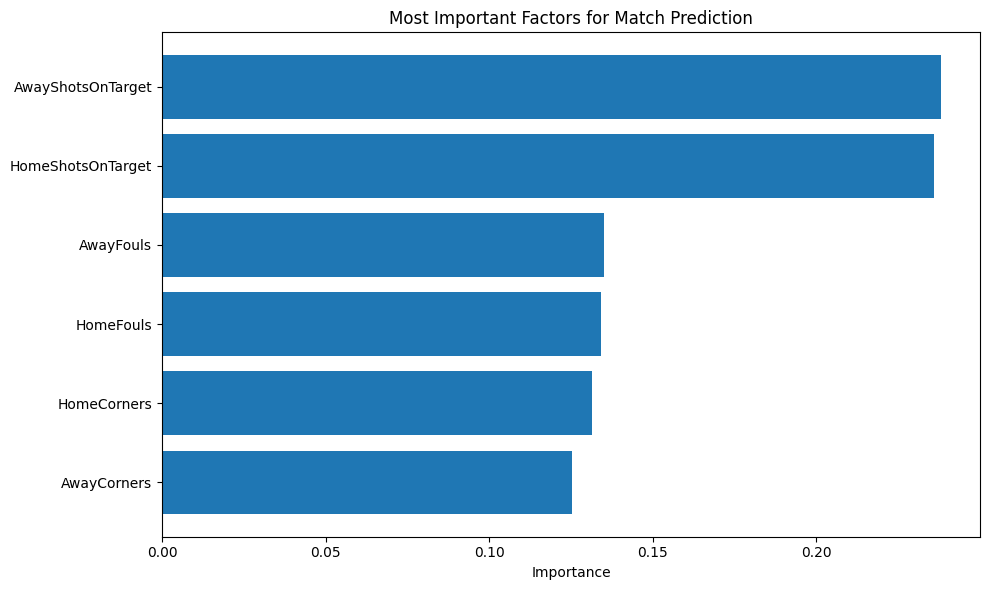

In [ ]:
# Which stats matter most?
importance_df = pd.DataFrame({
    'feature': predictive_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('Most Important Factors for Match Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

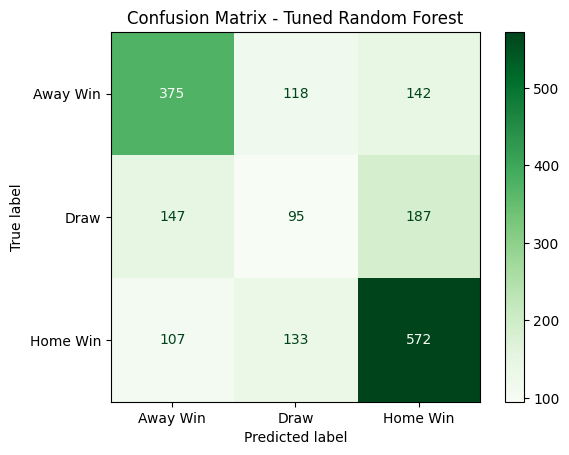

In [ ]:
# Confusion Matrix for Tuned Random Forest
cm_rf = confusion_matrix(y_test, rf_pred, labels=best_rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=best_rf.classes_)
disp.plot(cmap='Greens')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.show()

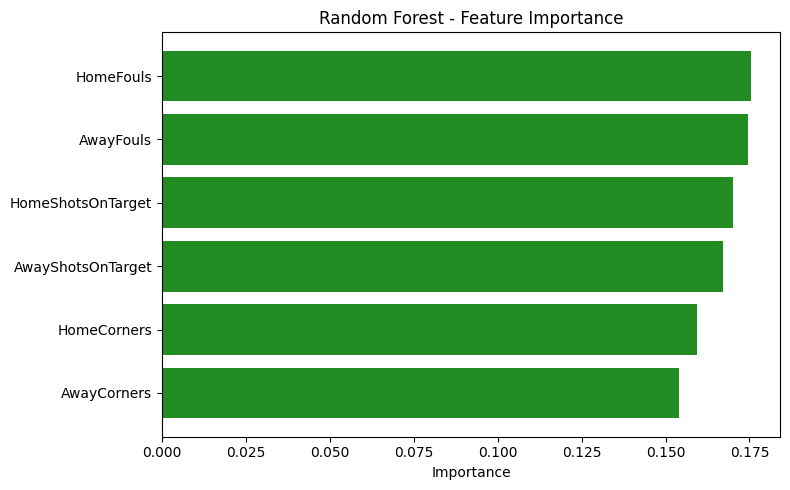

In [ ]:
# CELL X+3: Feature Importance
importance_df = pd.DataFrame({
    'Feature': predictive_features,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='forestgreen')
plt.xlabel('Importance')
plt.title('Random Forest - Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Random Forest Tuned - Feature Importance (Text Only)
importance_df_tuned = pd.DataFrame({
    'Feature': predictive_features,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*50)
print("RANDOM FOREST TUNED - FEATURE IMPORTANCE")
print("="*50)
for i, row in importance_df_tuned.iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.3f}")
print("\n🔑 Top 3 Most Important Factors:")
for i, row in importance_df_tuned.head(3).iterrows():
    print(f"  {i+1}. {row['Feature']}: {row['Importance']:.3f}")


RANDOM FOREST TUNED - FEATURE IMPORTANCE
  HomeFouls: 0.175
  AwayFouls: 0.175
  HomeShotsOnTarget: 0.170
  AwayShotsOnTarget: 0.167
  HomeCorners: 0.159
  AwayCorners: 0.154

🔑 Top 3 Most Important Factors:
  5. HomeFouls: 0.175
  6. AwayFouls: 0.175
  1. HomeShotsOnTarget: 0.170
